In [1]:
# notebook to plot the distribution of effect sizes in the filtered gtex data to check if there is some kind of bias away from positively skewed variants

In [26]:
# import packages
import pandas as pd
import seaborn as sns
from scipy import stats
from collections import Counter

In [12]:
# open the dataframe you passed to tian
allGTEx = pd.read_csv(
    'multiTF_cluster/results_final/highPIP_shadow_variants_allTissues.tsv',
    sep = '\t'
)
# add id for filtering
allGTEx.loc[:, 'filter_id'] = [('_').join([var, tissue, gene]) for var, tissue, gene in zip(allGTEx['variant_id_gtex'],
                                                                                            allGTEx['lead_tissue'],
                                                                                            allGTEx['gene_name'])]
# filter for only lead variants
leadVars = allGTEx[allGTEx['is_lead_variant'] == True].copy()                                                                                        

<Axes: xlabel='afc', ylabel='Count'>

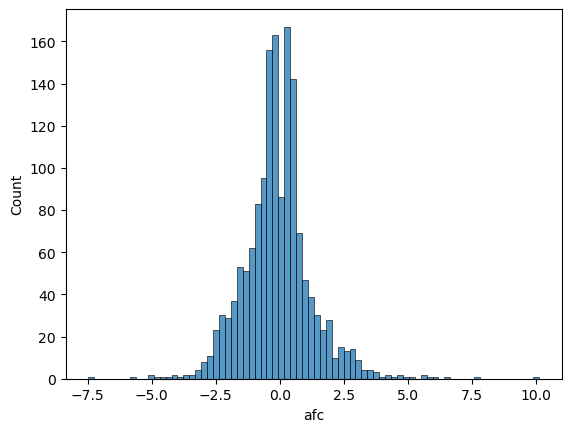

In [29]:
sns.histplot(
    data = leadVars.filter(['filter_id', 'afc']).drop_duplicates(),
    x = 'afc'
)

In [21]:
leadVars.loc[:, 'neg_skew'] = [1 if i < 0 else 0 for i in leadVars['afc']]

In [30]:
len(leadVars['filter_id'].unique())

1537

In [28]:
leadVars[leadVars['filter_id'] == '1_16696772_C_T_b38_Pancreas_ENSG00000280114']

,variant_id,chrom,pos,ref,alt,cell_type,skew_pred,abs_skew,enhancer_ids,af,...,af_gtex,afc,afc_se,cs_id,cs_size,variant_id_gtex,skew_fc_vs_lead,lead_skew_sign,filter_id,neg_skew
240,chr1:16696772:C:T,chr1,16696772,C,T,k562,-1.036563,1.036563,EH38E2789727,0.083488,...,0.074586,1.461053,0.261062,3,1,1_16696772_C_T_b38,1.0,-1,1_16696772_C_T_b38_Pancreas_ENSG00000280114,0
8046,chr1:16696772:C:T,chr1,16696772,C,T,hepg2,-0.670963,0.670963,EH38E2789727,0.083488,...,0.074586,1.461053,0.261062,3,1,1_16696772_C_T_b38,1.0,-1,1_16696772_C_T_b38_Pancreas_ENSG00000280114,0
13196,chr1:16696772:C:T,chr1,16696772,C,T,sknsh,-0.701610,0.701610,EH38E2789727,0.083488,...,0.074586,1.461053,0.261062,3,1,1_16696772_C_T_b38,1.0,-1,1_16696772_C_T_b38_Pancreas_ENSG00000280114,0


In [27]:
Counter(leadVars['filter_id'])

Counter({'1_16696772_C_T_b38_Pancreas_ENSG00000280114': 3,
         '1_16696772_C_T_b38_Thyroid_CROCCP2': 3,
         '1_1065797_G_C_b38_Spleen_ENSG00000217801': 3,
         '1_1065797_G_C_b38_Thyroid_ENSG00000217801': 3,
         '1_1292032_G_A_b38_Brain_Anterior_cingulate_cortex_BA24_MTCO1P12': 3,
         '1_1292032_G_A_b38_Brain_Caudate_basal_ganglia_MTND1P23': 3,
         '1_11986032_G_A_b38_Adipose_Subcutaneous_MFN2': 3,
         '1_11986032_G_A_b38_Cells_Cultured_fibroblasts_MFN2': 3,
         '1_11986032_G_A_b38_Spleen_MFN2': 3,
         '1_11986032_G_A_b38_Whole_Blood_PLOD1': 3,
         '1_1440430_C_G_b38_Adipose_Subcutaneous_ATAD3C': 3,
         '1_1440430_C_G_b38_Artery_Aorta_ATAD3C': 3,
         '1_1440430_C_G_b38_Artery_Coronary_ATAD3C': 3,
         '1_1440430_C_G_b38_Brain_Caudate_basal_ganglia_ATAD3C': 3,
         '1_1440430_C_G_b38_Brain_Nucleus_accumbens_basal_ganglia_ATAD3C': 3,
         '1_1440430_C_G_b38_Brain_Putamen_basal_ganglia_ATAD3C': 3,
         '1_1440430_C

In [22]:
leadVars['neg_skew'].value_counts()

neg_skew
1    1683
0    1348
Name: count, dtype: int64

In [19]:
leadVars.iloc[2,:]

variant_id                            chr1:16696772:C:T
chrom                                              chr1
pos                                            16696772
ref                                                   C
alt                                                   T
cell_type                                          k562
skew_pred                                     -1.036563
abs_skew                                       1.036563
enhancer_ids                               EH38E2789727
af                                             0.083488
AF_afr                                          0.17594
AF_ami                                         0.005482
AF_amr                                         0.041362
AF_asj                                         0.068127
AF_eas                                         0.000778
AF_fin                                         0.030948
AF_mid                                         0.024138
AF_nfe                                          

In [10]:
allGTEx.head()

,variant_id,chrom,pos,ref,alt,cell_type,skew_pred,abs_skew,enhancer_ids,af,...,biotype,af_gtex,afc,afc_se,cs_id,cs_size,variant_id_gtex,skew_fc_vs_lead,lead_skew_sign,filter_id
0,chr1:235647517:A:C,chr1,235647517,A,C,k562,0.122555,0.122555,EH38E2875581,0.000007,...,protein_coding,0.442688,-0.362746,0.135328,1,1,1_235647517_A_C_b38,0.159198,-1,chr1:235647538:G:A_Brain_Putamen_basal_ganglia...
1,chr1:235647519:C:T,chr1,235647519,C,T,k562,-0.063890,0.063890,EH38E2875581,0.000013,...,protein_coding,0.442688,-0.362746,0.135328,1,1,1_235647519_C_T_b38,0.082993,-1,chr1:235647538:G:A_Brain_Putamen_basal_ganglia...
2,chr1:235647531:G:A,chr1,235647531,G,A,k562,0.050092,0.050092,EH38E2875581,0.000013,...,protein_coding,0.442688,-0.362746,0.135328,1,1,1_235647531_G_A_b38,0.065069,-1,chr1:235647538:G:A_Brain_Putamen_basal_ganglia...
3,chr1:235647537:C:T,chr1,235647537,C,T,k562,-0.522557,0.522557,EH38E2875581,0.000007,...,protein_coding,0.442688,-0.362746,0.135328,1,1,1_235647537_C_T_b38,0.678801,-1,chr1:235647538:G:A_Brain_Putamen_basal_ganglia...
4,chr1:235647538:G:A,chr1,235647538,G,A,k562,-0.769824,0.769824,EH38E2875581,0.411064,...,protein_coding,0.442688,-0.362746,0.135328,1,1,1_235647538_G_A_b38,1.000000,-1,chr1:235647538:G:A_Brain_Putamen_basal_ganglia...


In [11]:
allGTEx['is_lead_variant']

0         False
1         False
2         False
3         False
4          True
          ...  
216040    False
216041    False
216042    False
216043    False
216044    False
Name: is_lead_variant, Length: 216045, dtype: bool